In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import warnings
warnings.filterwarnings("ignore")
import sys
sys.path.append('/home/future_commodity')
import pandas as pd
import numpy as np
np.seterr(all='ignore')
import lightgbm as lgb
from pathlib import Path
import os
from typing import List, Tuple
import function_future.pre_train as pt
import function_future.train_model as tm
import function_future.FactorFilter as FF
import function_future.backtest_v3 as bv
import function_future.DataLoader as DL, function_future.date_selection as DS
import function_future.trading_visualization as TV
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from joblib import Parallel, delayed
import re


In [ ]:
symbol = 'RR'
train_label = 5
train_end_date = '2025-07-01'

folder_name = f'{symbol}_pred{train_label}_{train_end_date}_v0'

rtn_mul = 1
config_loader = DL.InstrumentConfig()
config_loader.get_instrument_config(symbol)

{'symbol': 'RR',
 'contract_multiplier': 10,
 'price_tick': 1,
 'margin_rate': 0.06,
 'fee': 0.0,
 'fee_way': 'number',
 'fee_comment': '平今',
 'trading_hours': ['09:00-11:30', '13:30-15:00', '21:00-23:00'],
 'light': 1,
 'night': 1,
 'exchange': 'dce',
 'name': '梗米'}

In [4]:
fac_df = pd.read_feather(f'/mnt/Data/writable/liaoyuyang/factor/{symbol}/all_fac/all_factor.feather').set_index(['datetime']).loc[:train_end_date]
fac_df = config_loader.df_cut_time(fac_df, config_loader.get_instrument_config(symbol)['trading_hours'], 10)

exclude_factors = [
        'datetime', 'instrument',
        ]

factor_col = [x for x in fac_df.columns if x not in exclude_factors]

main_fac_piv = fac_df[factor_col]
rtn_df = pd.read_csv(f'/mnt/Data/writable/liaoyuyang/data/1min/active/main_{symbol}.csv', index_col=0, parse_dates=['ts']).set_index('ts').reindex(index=fac_df.index)
main_fac_piv['pred_ret'] = rtn_df[f'rtn_{train_label}']
main_fac_piv = main_fac_piv.replace([np.inf, -np.inf], np.nan)
main_fac_piv['hour'] = main_fac_piv.index.hour

main_fac_piv['pred_ret'].hist(bins=100, figsize=(8, 3), alpha=0.7, color='blue')
plt.grid(True, alpha=0.3)
plt.show()

pretrainer = pt.Pretrainer(symbol, main_fac_piv, train_end_date, train_label=train_label)

importance = pretrainer.run_full_pretraining(type_lgb = 'reg')

KeyboardInterrupt: 

In [ ]:
factor_info = pd.read_csv(f'/mnt/Data/writable/liaoyuyang/factor_eval_commodity/{train_end_date}/{symbol}_single_factor_eval_{train_label}.csv', index_col=0)
importance_df = pd.read_csv(f'/mnt/Data/writable/liaoyuyang/factor_eval_commodity/{train_end_date}/importance/{train_end_date}_{symbol}_{train_label}_feature_importance_reg.csv')
corr_df = pd.read_csv(f'/mnt/Data/writable/liaoyuyang/factor_eval_commodity/{train_end_date}/correlation/{train_end_date}_{symbol}_{train_label}_feature_corr.csv', index_col=0)
group_df = pd.read_csv(f'/mnt/Data/writable/liaoyuyang/factor_eval_commodity/{train_end_date}/group/{train_end_date}_{symbol}_{train_label}_feature_group.csv')
factor_to_choose = main_fac_piv.columns[:-1]

factor_filter = FF.FactorFilter(importance_df, corr_df, group_df, factor_info, factor_to_choose)
print([x for x in factor_filter.factor_to_choose if x not in factor_info.index])
params = {
    "info_select_params": {"nan_rate": 0.8, "mode_rate": 0.9},
    "importance_select_by_group_params" : {"cut_num_1": 300, "cut_num_2":200, "same_name_cut": 5}, 
    "corr_select_params": {"feature_num_limit": 300, "corr_limit": 0.9}, 
    "sp_select": {"th":0.5},
    "day_cut": {"num_limit":5},
    "exclude_factors": [
            'datetime', 'instrument',
            'JC1D', 'ZCpriceinterval', 'ptvol5',
            'JC2H'
            ]
}
factor_filter.run_selection(**params)

lst1 = [x for x in factor_filter.factor_to_choose if x.startswith('FAC')]
lst2 = [x for x in factor_filter.factor_to_choose if x.startswith('STK')]
lst3 = [x for x in factor_filter.factor_to_choose if re.match(r'^(_C|_CS|_RR|_JD|_LH|_AP|_CJ|_SR|_CF|_CY|C_|CS_|RR_|JD_|LH_|AP_|CJ_|SR_|CF_|CY_)', x)]
lst4 = [x for x in factor_filter.factor_to_choose if x not in lst1+lst2+lst3]
len(lst1), len(lst2), len(lst3), len(lst4)

['pred_ret']
特征分布性过滤：
筛选之前因子数量：1885， 筛选之后因子数量：1786

特征重要性过滤： 300 200 	待筛因子个数 1786
无向因子有效个数： 693 有向因子有效个数： 1150
  选择有向特征 223 个，重要性范围: 3529.00 - 79.00
  选择无向特征 145 个，重要性范围: 4303.00 - 238.00

单因子sharpe过滤： 0.5 sp范围-25.7981 ~ 24.2346   待筛因子个数 368

特征相关性性过滤： 300     待筛因子个数 331
  选择特征 300 个, 特征最大相关性0.8982562428171036

已挑选日频开盘因子数量： 5 ['day_first4redcorr', 'day_first4greencorr', 'day_jump', 'day_first10rev', 'day_first3power']

保留日频开盘因子数量： 5 ['day_first4redcorr', 'day_first4greencorr', 'day_jump', 'day_first10rev', 'day_first3power']

排除指定因子后，剩余特征 299 个


(219, 0, 53, 27)

正在从 /mnt/Data/writable/liaoyuyang/factor/RR/all_fac/all_factor.feather 加载数据...
训练数据加载完成，形状: (263184, 1889)
训练集时间范围: 2021-02-02 09:11:00 至 2024-12-31 14:49:00
[200]	valid_0's rmse: 0.924318
[400]	valid_0's rmse: 0.923325
[600]	valid_0's rmse: 0.922831
[800]	valid_0's rmse: 0.922499
[1000]	valid_0's rmse: 0.922406
[1200]	valid_0's rmse: 0.922336
[1400]	valid_0's rmse: 0.92231
[1600]	valid_0's rmse: 0.922338
[1800]	valid_0's rmse: 0.922397


<Figure size 1000x600 with 0 Axes>

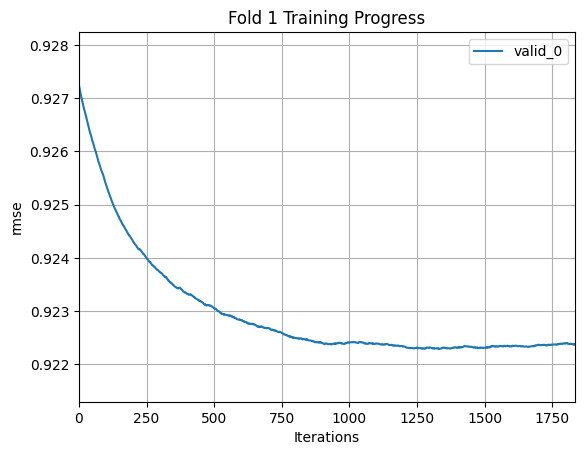

{'train_rmse': np.float64(0.9764156837312231), 'val_rmse': np.float64(0.9943496380962852), 'best_iteration': 1333}
test_corr: 0.1074
[200]	valid_0's rmse: 0.874287
[400]	valid_0's rmse: 0.872671
[600]	valid_0's rmse: 0.871734
[800]	valid_0's rmse: 0.871177
[1000]	valid_0's rmse: 0.870803
[1200]	valid_0's rmse: 0.870619
[1400]	valid_0's rmse: 0.870585
[1600]	valid_0's rmse: 0.87055
[1800]	valid_0's rmse: 0.870563
[2000]	valid_0's rmse: 0.870587


<Figure size 1000x600 with 0 Axes>

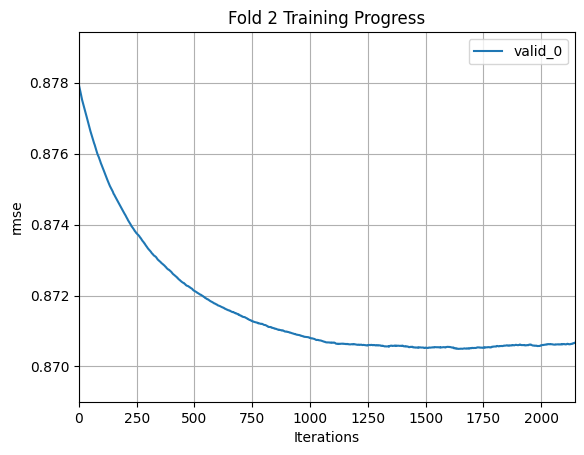

{'train_rmse': np.float64(0.9707208329355937), 'val_rmse': np.float64(0.9916942988716838), 'best_iteration': 1646}
test_corr: 0.1105
[200]	valid_0's rmse: 0.768106
[400]	valid_0's rmse: 0.767325
[600]	valid_0's rmse: 0.766881
[800]	valid_0's rmse: 0.766548
[1000]	valid_0's rmse: 0.766336
[1200]	valid_0's rmse: 0.76615
[1400]	valid_0's rmse: 0.766014
[1600]	valid_0's rmse: 0.765937
[1800]	valid_0's rmse: 0.765911
[2000]	valid_0's rmse: 0.765855
[2200]	valid_0's rmse: 0.765823
[2400]	valid_0's rmse: 0.765793
[2600]	valid_0's rmse: 0.765763
[2800]	valid_0's rmse: 0.765714
[3000]	valid_0's rmse: 0.765728
[3200]	valid_0's rmse: 0.765731
[3400]	valid_0's rmse: 0.76573


<Figure size 1000x600 with 0 Axes>

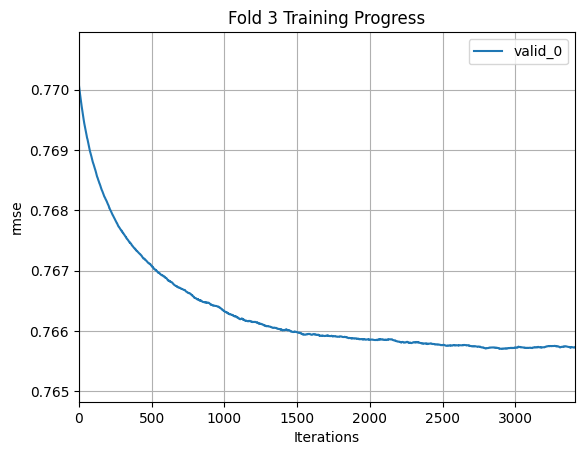

{'train_rmse': np.float64(0.9572110308756312), 'val_rmse': np.float64(0.9933096136546608), 'best_iteration': 2910}
test_corr: 0.1001
[200]	valid_0's rmse: 0.671129
[400]	valid_0's rmse: 0.670749
[600]	valid_0's rmse: 0.67069
[800]	valid_0's rmse: 0.670829
[1000]	valid_0's rmse: 0.670917


<Figure size 1000x600 with 0 Axes>

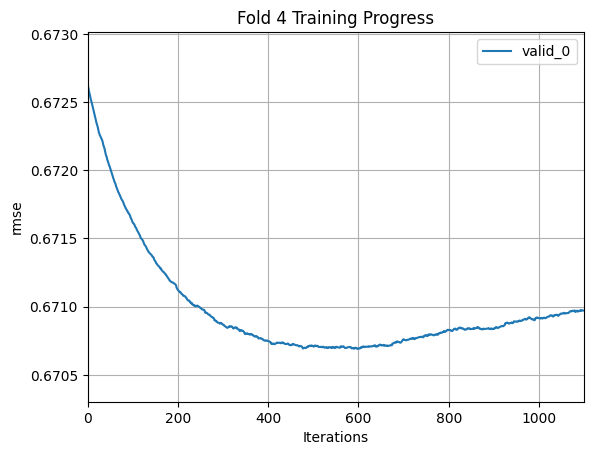

{'train_rmse': np.float64(0.9843762808186965), 'val_rmse': np.float64(0.9960497717374825), 'best_iteration': 599}
test_corr: 0.1071
[200]	valid_0's rmse: 0.501493
[400]	valid_0's rmse: 0.501016
[600]	valid_0's rmse: 0.500815
[800]	valid_0's rmse: 0.500753
[1000]	valid_0's rmse: 0.500761
[1200]	valid_0's rmse: 0.500779


<Figure size 1000x600 with 0 Axes>

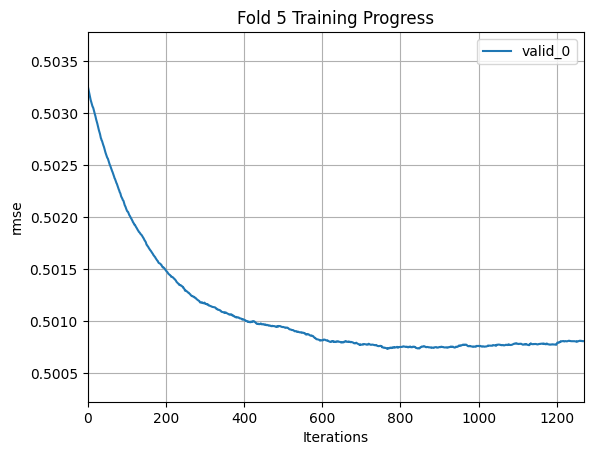

{'train_rmse': np.float64(0.9828256639370819), 'val_rmse': np.float64(0.9933824892122952), 'best_iteration': 768}
test_corr: 0.1042


In [ ]:
analyzer = tm.TimeSeriesAnalyzer(
    symbol = symbol,
    factor_col = factor_filter.factor_to_choose,
    train_end_date = train_end_date,
    config_loader = config_loader
)
analyzer.load_and_prepare_data(log_rtn=True, set_category_col=['hour'], label_col=f'rtn_{train_label}', cut=True)
trainer = tm.LGBMTrainer(analyzer)
_ = trainer.train_kfold_v0(custom_params={'verbose':-1}, model_folder_name=folder_name, plot_train=True, n_splits=5)

In [ ]:
config = bv.load_config(r"/mnt/Data/writable/liaoyuyang/backtest/backtest_config.json")
config['MODEL_DIR'] = Path(config['MODEL_DIR']) / str(folder_name)
config

{'MODEL_DIR': PosixPath('/mnt/Data/writable/liaoyuyang/model/lightgbm/KFoldModel/models/RR_pred5_2025-01-01_v0'),
 'OUTPUT_DIR': '/mnt/Data/writable/liaoyuyang/backtest/results',
 'pic_dir': '/mnt/Data/writable/liaoyuyang/backtest/pic',
 'feature_dir': '/mnt/Data/writable/liaoyuyang/backtest/data/features',
 'pred_label_dir': '/mnt/Data/writable/liaoyuyang/backtest/data/predictions',
 'merged_output_dir': '/mnt/Data/writable/liaoyuyang/backtest/data/merged',
 'start_date': '20180101',
 'end_date': '20260101',
 'ts_col': 'datetime',
 'instrument_col': 'instrument',
 'target_col': 'pred_ret',
 'holding_price_col': 'close',
 'trading_price_col': 'tick6t60avg',
 'pos_col': 'pos',
 'category_col': ['hour'],
 'factor_col': 'factor',
 'filter_dict': {'exclude_night': True},
 'auto_create_dirs': True}

In [ ]:
bt = bv.ModelBacktester(train_end_date, config)
bt.load_config(symbol)
bt.window_end = '2027-01-01'
bt.money = 2_000_000 
bt.fee = 0

bt.load_factor(symbol, end_date=bt.window_end)
bt.load_mktdata(symbol, end_date=bt.window_end)
bt.load_models()
bt.generate_predictions()
pred = bt.combine_models('best_iteration_log_weighted', avg=True)

In [ ]:
bt.mkt_data

,datetime,instrument,open,high,low,close,last_twap,mid_price,volume,turnover,...,spread,bar_count,trade_date,tick10avg,tick0t10avg,tick6t15avg,tick6t60avg,rtn_1,rtn_5,rtn_10
0,2021-02-02 09:01:00,rr2104,3654.0,3656.0,3654.0,3656.0,3655.000000,3655.703075,10.0,365510.0,...,2.500000,29,2021-02-02,NaN,3654.000,3654.428571,3655.111111,-0.000102,0.000395,0.000447
1,2021-02-02 09:02:00,rr2104,3656.0,3657.0,3656.0,3657.0,3656.294118,3657.709300,4.0,146270.0,...,2.000000,29,2021-02-02,NaN,3656.000,3656.000000,3656.555556,0.000265,0.000508,0.000504
2,2021-02-02 09:03:00,rr2104,3657.0,3657.0,3656.0,3656.0,3656.181818,3657.497564,5.0,182800.0,...,2.000000,13,2021-02-02,NaN,NaN,3657.000000,3656.181818,0.000223,0.000232,0.000232
3,2021-02-02 09:04:00,rr2104,3656.0,3658.0,3656.0,3657.0,3657.095238,3657.373495,13.0,475460.0,...,1.571429,25,2021-02-02,3657.10,3656.000,NaN,3657.150000,0.000009,0.000069,-0.000219
4,2021-02-02 09:05:00,rr2104,3657.0,3658.0,3657.0,3658.0,3657.959350,3658.090585,34.0,1243720.0,...,1.105691,129,2021-02-02,3657.75,3657.500,3657.714286,3657.966387,0.000000,0.000026,-0.000273
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
378964,2026-03-09 14:56:00,rr2604,3625.0,3625.0,3625.0,3625.0,3625.000000,3625.113711,11.0,398750.0,...,1.000000,35,2026-03-09,3625.00,3625.000,3625.000000,3625.000000,0.000350,0.000665,0.001379
378965,2026-03-09 14:57:00,rr2604,3625.0,3625.0,3625.0,3625.0,3625.000000,3625.398320,0.0,0.0,...,1.000000,10,2026-03-09,NaN,3625.000,3625.000000,3625.000000,0.000202,-0.000867,0.000876
378966,2026-03-09 14:58:00,rr2604,3625.0,3627.0,3625.0,3627.0,3626.269231,3626.691992,7.0,253840.0,...,1.461538,26,2026-03-09,3626.05,NaN,NaN,3626.269231,0.000146,-0.001180,0.000254
378967,2026-03-09 14:59:00,rr2604,3627.0,3627.0,3627.0,3627.0,3627.000000,3627.036239,2.0,72540.0,...,1.666667,18,2026-03-09,NaN,3627.000,3627.000000,3627.000000,0.000038,-0.001249,-0.000146


In [ ]:
merged_data = bt.backtest(th1=0.9, th2=0.5, save=False, open_drop=True, holding_bars=10,
                           day=5*345, model_name='best_iteration_log_weighted', v=2
                        )

trading_hours ['09:00-11:30', '13:30-15:00', '21:00-23:00']


  0%|          | 0/85767 [00:00<?, ?it/s]

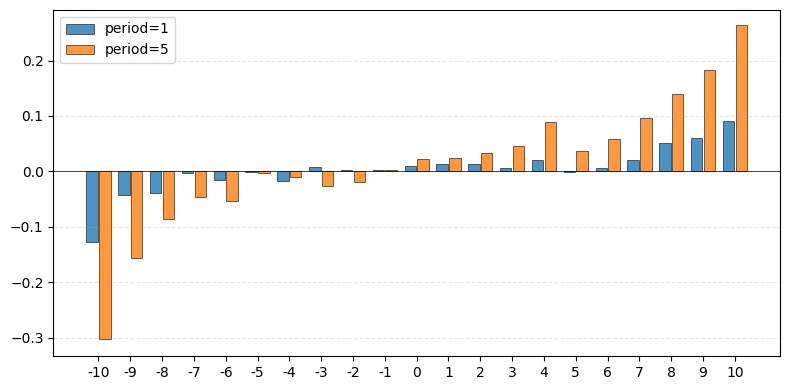

In [ ]:
fig = bv.plot_group_bar(merged_data, periods=[1,5], trading_hours=["09:00-11:30", "13:30-15:00", "21:00-01:00"], g=21)

In [ ]:
bv.analyze_pos_distribution(merged_data)

,统计值
多头(+1) 数量,17884
空头(-1) 数量,17523
空仓(0) 数量,50362
多头占比,20.85%
空头占比,20.43%
空仓占比,58.72%
交易日数量,266
总收益(非年化%),6.27
总交易次数（开平算一次）,3412
日均交易次数（开平算一次）,12.83


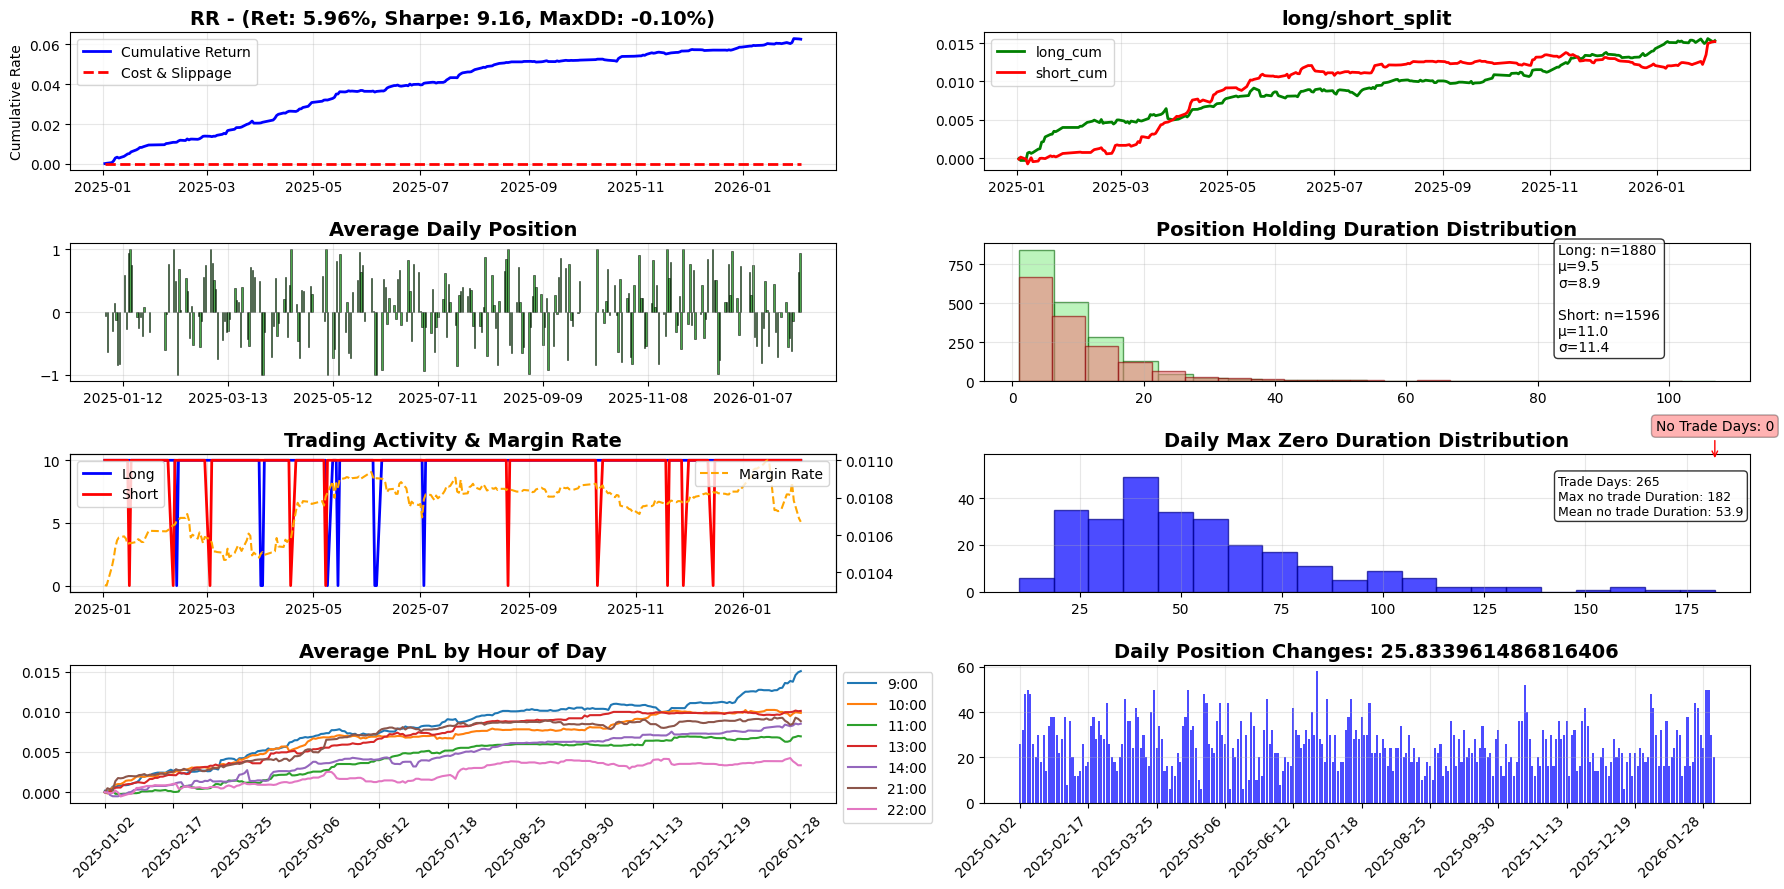

In [ ]:
fig = bv.plot_eval(symbol, merged_data, "无")

In [ ]:
tvp = TV.TradingVisualizationPager(symbol=symbol, data = merged_data, skip_weekends=True)
tvp.run()

Output()

✅ 交易可视化工具已启动
📈 品种: RR
📅 总交易日数: 265
📊 总数据点: 96195
🎯 使用导航按钮或输入页码进行浏览


In [ ]:
bv.plot_yearly_eval(merged_data)